In [1]:
from google.colab import files
uploaded = files.upload()

Saving processedElectrical_fault_data.csv to processedElectrical_fault_data.csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, r2_score, accuracy_score
from sklearn.utils import resample

# 1. Load the data
df = pd.read_csv('processedElectrical_fault_data.csv')

# 2. Filter out 'Healthy' (Normal) data
df_faults = df[df['fault_severity_level'] != 'Healthy'].copy()

# 3. Balance the dataset to 20,000 samples per class
target_size = 20000
balanced_list = []
for level in df_faults['fault_severity_level'].unique():
    subset = df_faults[df_faults['fault_severity_level'] == level]
    # Upsample if smaller than target, downsample if larger
    resampled_subset = resample(subset,
                                replace=(len(subset) < target_size),
                                n_samples=target_size,
                                random_state=42)
    balanced_list.append(resampled_subset)

df_balanced = pd.concat(balanced_list).sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Feature and Target Separation
target_cols = ['fault_severity_level', 'fault_severity_value', 'strings_affected','power_loss_ratio']
X = df_balanced.drop(columns=target_cols)

y_level = df_balanced['fault_severity_level']
y_value = df_balanced['fault_severity_value']
y_strings = df_balanced['strings_affected']
y_power_loss = df_balanced['power_loss_ratio']

# Encode the categorical target (Level)
le = LabelEncoder()
y_level_encoded = le.fit_transform(y_level)

# 5. Split and Scale
X_train, X_test, y_level_train, y_level_test, y_value_train, y_value_test, y_strings_train, y_strings_test, y_power_loss_train, y_power_loss_test = train_test_split(
    X, y_level_encoded, y_value, y_strings, y_power_loss, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Training Models
# Using n_jobs=-1 for faster training with more data
clf_level = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_level.fit(X_train_scaled, y_level_train)

reg_value = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg_value.fit(X_train_scaled, y_value_train)

clf_strings = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_strings.fit(X_train_scaled, y_strings_train)

reg_power_loss = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg_power_loss.fit(X_train_scaled, y_power_loss_train)

# 7. Evaluation
print("1. Severity Level Accuracy:", accuracy_score(y_level_test, clf_level.predict(X_test_scaled)))
print("2. Severity Value R2 Score:", r2_score(y_value_test, reg_value.predict(X_test_scaled)))
print("3. Strings Affected Accuracy:", accuracy_score(y_strings_test, clf_strings.predict(X_test_scaled)))
print("4. Power Loss Ratio R2 Score:", r2_score(y_power_loss_test, reg_power_loss.predict(X_test_scaled)))

1. Severity Level Accuracy: 0.9986875
2. Severity Value R2 Score: 0.9999975030781706
3. Strings Affected Accuracy: 1.0
4. Power Loss Ratio R2 Score: 0.9990680672721629


### Classification Report and Confusion Matrix for 'fault_severity_level'

### Classification Report and Confusion Matrix for 'strings_affected'


--- Classification Report for Fault Severity Level ---
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00      3982
        High       1.00      1.00      1.00      3934
         Low       1.00      1.00      1.00      4076
      Medium       1.00      1.00      1.00      4008

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000



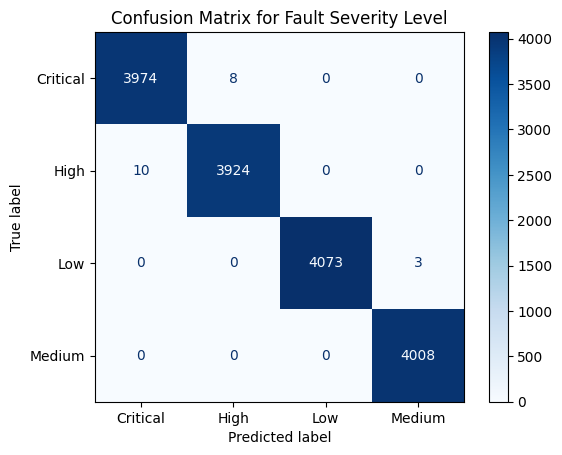

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Predictions for severity level
y_level_pred = clf_level.predict(X_test_scaled)

# Get original labels for readability
class_names_level = le.classes_

# Classification Report
print("\n--- Classification Report for Fault Severity Level ---")
print(classification_report(y_level_test, y_level_pred, target_names=class_names_level))

# Confusion Matrix
cm_level = confusion_matrix(y_level_test, y_level_pred)
disp_level = ConfusionMatrixDisplay(confusion_matrix=cm_level, display_labels=class_names_level)
disp_level.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Fault Severity Level')
plt.show()